In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
df=pd.read_csv('Stores.csv')

In [126]:
df.shape

(118, 7)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Store Number     118 non-null    int64  
 1   AreaStore        118 non-null    float64
 2   Property         118 non-null    object 
 3   Type             118 non-null    object 
 4   Old/New          118 non-null    object 
 5   Checkout Number  106 non-null    float64
 6   Revenue          118 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 6.6+ KB


In [128]:
df.isnull().any()

,0
Store Number,False
AreaStore,False
Property,False
Type,False
Old/New,False
Checkout Number,True
Revenue,False


In [129]:
df.isnull().sum()

,0
Store Number,0
AreaStore,0
Property,0
Type,0
Old/New,0
Checkout Number,12
Revenue,0


In [130]:
df['Checkout Number']=df['Checkout Number'].fillna(df['Checkout Number'].mean())

In [131]:
df['Checkout Number']

,Checkout Number
0,6.000000
1,5.000000
2,4.792453
3,9.000000
4,2.000000
...,...
113,9.000000
114,6.000000
115,2.000000
116,2.000000


In [132]:
df.isnull().sum()

,0
Store Number,0
AreaStore,0
Property,0
Type,0
Old/New,0
Checkout Number,0
Revenue,0


In [133]:
df.head(5)

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue
0,1,2100.0,Owned,Hyper,New,6.000000,"45,072,000"
1,2,1290.0,Cooperate,Extra,New,5.000000,"7,416,000"
2,3,500.0,Rental,Express,New,4.792453,"8,592,000"
3,4,2000.0,Owned,Hyper,New,9.000000,"48,415,500"
4,5,220.0,Rental,Express,Old,2.000000,"3,345,500"


In [134]:
df['Revenue_N']=df['Revenue'].str.replace(',','').astype(int,copy=True)

In [135]:
df['Revenue_N']

,Revenue_N
0,45072000
1,7416000
2,8592000
3,48415500
4,3345500
...,...
113,13471000
114,29974500
115,11031500
116,6173500


In [136]:
df.describe()

,Store Number,AreaStore,Checkout Number,Revenue_N
count,118.000000,118.000000,118.000000,1.180000e+02
mean,59.500000,1373.608136,4.792453,2.299805e+07
std,34.207699,1092.453470,2.672164,2.051452e+07
min,1.000000,82.000000,1.000000,2.336000e+06
25%,30.250000,530.500000,3.000000,9.021375e+06
50%,59.500000,1000.000000,4.000000,1.358475e+07
75%,88.750000,1887.500000,6.000000,3.105050e+07
max,118.000000,5600.000000,14.000000,1.000830e+08


In [137]:
df['Revenue_N']=df['Revenue_N']/1000000000
#This will make the revenue in billion

In [138]:
df['Revenue_N']

,Revenue_N
0,0.045072
1,0.007416
2,0.008592
3,0.048416
4,0.003345
...,...
113,0.013471
114,0.029975
115,0.011031
116,0.006174


In [139]:
df['Revenue_N'].dtype

dtype('float64')

In [140]:
df['Revenue'].dtype

dtype('O')

# Q1- WHICH TYPE OF STORE GENERATES THE HIGHEST REVENUE?

In [141]:
df['Revenue']=df['Revenue_N']

In [142]:
dat=df.groupby('Type', as_index=False)[['Revenue']].sum()

In [143]:
print(dat)

      Type   Revenue
0  Express  0.582987
1    Extra  0.881789
2    Hyper  1.248994


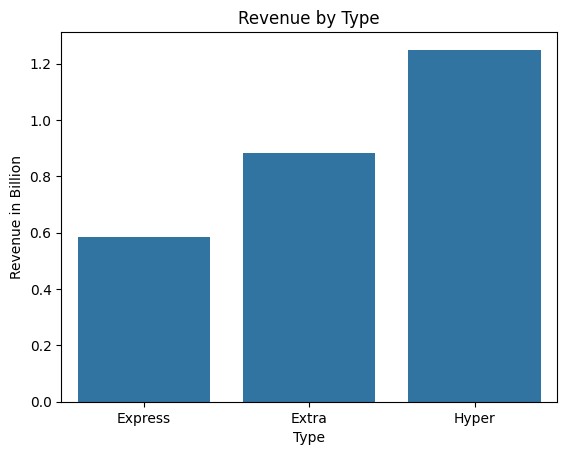

In [144]:
sns.barplot(data=dat,x='Type',y='Revenue')
plt.xlabel('Type')
plt.ylabel('Revenue in Billion')
plt.title('Revenue by Type')
plt.show()


 CONCLUSION:- Hyper stores generate the highest total revenue at approximately ₹1.25 billion, followed by Extra stores at ₹0.88 billion and Express stores at ₹0.58 billion. This suggests that larger format stores (Hyper) are significantly more profitable in terms of total revenue. Businesses should consider expanding the Hyper format in new locations to maximize revenue potential.

In [145]:
df.head()

,Store Number,AreaStore,Property,Type,Old/New,Checkout Number,Revenue,Revenue_N
0,1,2100.0,Owned,Hyper,New,6.000000,0.045072,0.045072
1,2,1290.0,Cooperate,Extra,New,5.000000,0.007416,0.007416
2,3,500.0,Rental,Express,New,4.792453,0.008592,0.008592
3,4,2000.0,Owned,Hyper,New,9.000000,0.048416,0.048416
4,5,220.0,Rental,Express,Old,2.000000,0.003345,0.003345


# Q2-  TOP 10 LOWEST REVENUE STORES?

In [146]:
Bot=df.groupby('Store Number',as_index=False)[['Revenue']].sum().reset_index().sort_values(by='Revenue',ascending=True).head(10)

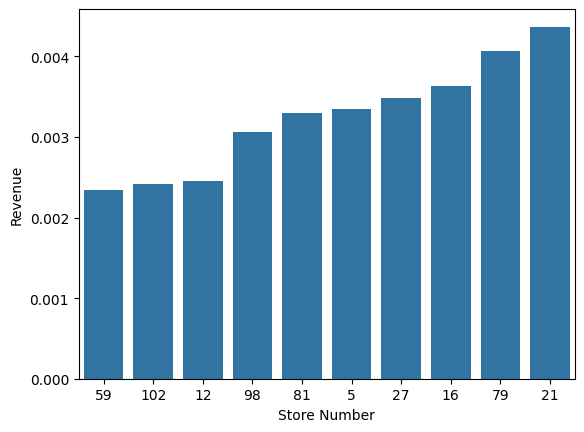

In [147]:
sns.barplot(data=Bot,x='Store Number',y='Revenue',order=Bot.sort_values('Revenue',ascending=True)['Store Number'])
plt.show()

 CONCLUSION:-  The 10 lowest-performing stores (Store Numbers 59, 102, 12, 98, 81, 5, 27, 16, 79, 21) all generate revenue below ₹0.005 billion. These stores may be underperforming due to small store area, fewer checkout counters, or poor location

# Q3- REVENUE AND REVENUE PERCENTAGE OF OLD AND NEW STORES?

In [148]:
df['Old/New'] = df['Old/New'].str.strip().str.title()

In [149]:
OL=df.groupby('Old/New',as_index=False)[['Revenue']].sum().sort_values('Revenue',ascending=True)

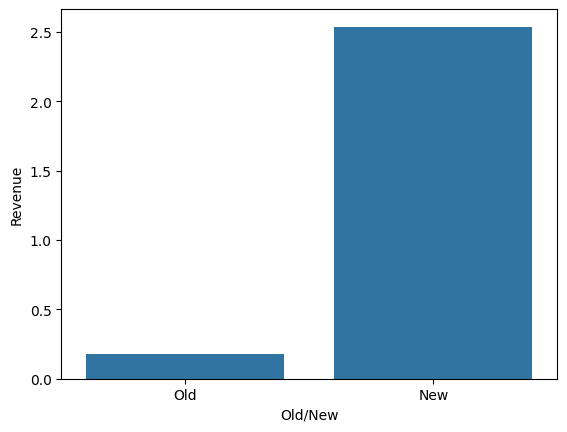

In [150]:
sns.barplot(data=OL,x='Old/New',y='Revenue')
plt.show()

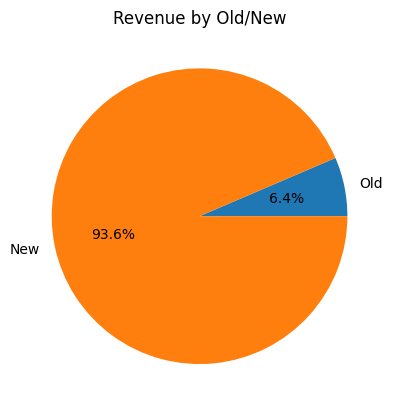

In [151]:
plt.pie(OL['Revenue'],labels=OL['Old/New'],autopct='%1.1f%%')
plt.title('Revenue by Old/New')
plt.show()

CONCLUSION:- New stores dominate with 93.6% of total revenue, while Old stores contribute only 6.4%. This is a strong indicator that newer stores are either larger, better located, or more efficiently run

In [152]:
print(OL)

  Old/New  Revenue
1     Old  0.17490
0     New  2.53887


# Q4 - IS THE REVENUE AFFECTED BY AREA STORE?

In [153]:
Sca=df.groupby('AreaStore',as_index=False)[['Revenue']].sum()

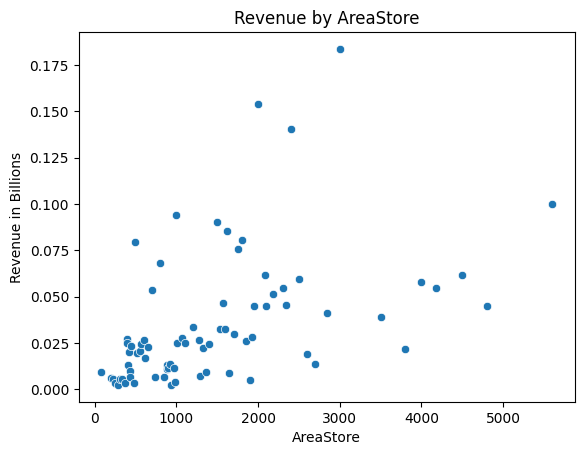

In [154]:
sns.scatterplot(data=Sca,x='AreaStore',y='Revenue')
plt.ylabel('Revenue in Billions')
plt.xlabel('AreaStore')
plt.title('Revenue by AreaStore')
plt.show()

CONCLUSION:- The scatter plot shows a moderate positive relationship between store area (AreaStore) and revenue — larger stores tend to generate more revenue. However, the relationship is not perfectly linear, as some smaller stores also show decent revenue, and a few large stores underperform

# Q5 - What is the correlation between Revenue, AreaStore, and Checkout Number?

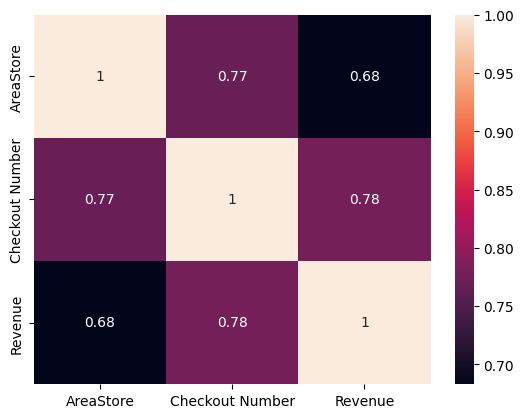

In [155]:
sns.heatmap(
    df[['AreaStore',
        'Checkout Number',
        'Revenue']].corr(),
    annot=True
)
plt.show()

CONCLUSION:- The heatmap reveals that Checkout Number has the strongest correlation with Revenue (0.78), meaning stores with more checkout counters tend to earn more. AreaStore also correlates well with both Checkout Number (0.77) and Revenue (0.68), which makes sense — bigger stores have more checkouts and higher sales.

#Q6 -What is the distribution of store revenues?

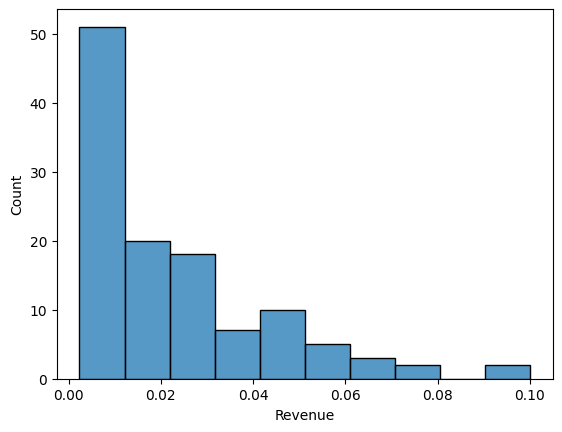

In [156]:
sns.histplot(
    df['Revenue'],
    bins=10
)
plt.show()

CONCLUSION:- The histogram shows that revenue distribution is right-skewed — the majority of stores earn relatively low revenue (below ₹0.02 billion), while a few high-performing stores pull the average up

# Q7-HOW DOES THE REVENUE DISTRIBUTION VARY ACROSS DIFFERENT STORE TYPES, AND ARE THERE ANY OUTLIERS?

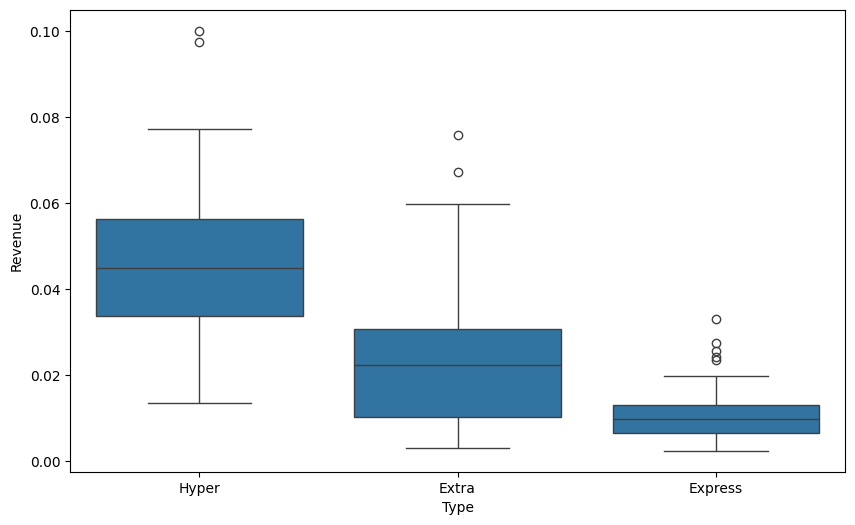

In [157]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Type',
    y='Revenue',
    data=df
)
plt.show()

CONCLUSION- The boxplot confirms this, showing that Hyper stores have the widest revenue spread and contain an outlier (Store 8) earning significantly above the rest. Express stores are the most consistent but lowest earning. This skew means the average revenue is not a good representation of a typical store — the median would be a better measure.

#               OVERALL CONCLUSION
# This EDA was performed on 118 stores across 7 variables. After data cleaning and analysis, the key findings are:\

1.Hyper stores generate the most revenue (₹1.25B) and should be prioritized for expansion.
2. New stores contribute 93.6% of total revenue — old stores need urgent renovation or replacement.

3.Checkout Number is the strongest revenue driver (r = 0.78) — more counters directly means more revenue.

4.Store area moderately affects revenue (r = 0.68) — bigger stores earn more, but it's not the only factor.

5.Revenue is right-skewed — most stores earn below ₹0.02B, while a few high performers pull the average up.


6.Store 8 is a major outlier — it should be studied as a best-practice model for other Hyper stores.


7.Bottom 10 stores (59, 102, 12, 98 etc.) earn below ₹0.005B and need immediate review.
